## **Simple LLM Sequential workflow**

In [ ]:
!pip install langchain langchain_openai langgraph

In [ ]:
from typing import TypedDict

In [ ]:
class LLMstate(TypedDict):

  question:str
  answer:str

In [ ]:
OPENAI_API_KEY = "your api key"

In [ ]:
from langchain_openai import ChatOpenAI
model = ChatOpenAI(model='gpt-4o-mini', api_key=OPENAI_API_KEY)

In [ ]:
def llm_qa(state:LLMstate) ->LLMstate:

  question = state['question']

  prompt = f'generate a short answer of this question: \n {question}'

  answer = model.invoke(prompt)

  state['answer'] = answer

  return state

In [ ]:
from langgraph.graph import StateGraph, START, END

In [ ]:
#create our graph

graph = StateGraph(LLMstate)

#add node
graph.add_node('llm_qa', llm_qa)

#add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow = graph.compile()

In [ ]:
#execute

initial_state = {'question': 'what is ai?'}

final_state = workflow.invoke(initial_state)

print(final_state['answer'].content)

Artificial Intelligence (AI) is a branch of computer science that focuses on creating systems capable of performing tasks that typically require human intelligence, such as understanding language, recognizing patterns, solving problems, and making decisions.


## **Linkedin Post Generator in Langgraph**

User Topic
   
       ↓

Research Node

       ↓

Summary Node

       ↓

Post Generator Node

       ↓

Final Output


In [ ]:
from langgraph.graph import StateGraph
from typing import TypedDict
from langchain_openai import ChatOpenAI

In [ ]:
class AgentState(TypedDict):
  topic: str
  research: str
  summary: str
  post: str

In [ ]:
llm = ChatOpenAI(model='gpt-4o-mini', api_key=OPENAI_API_KEY)

In [ ]:
#research node
def research_generation(state:AgentState) -> AgentState:

  topic = state["topic"]

  prompt = f'Research on this topic: {topic}'

  llm_research = llm.invoke(prompt).content
  state['research'] = llm_research

  return state

In [ ]:
#summary node
def summary_generation(state:AgentState) -> AgentState:

  topic_research = state['research']
  prompt = f'generate a summary based on this research: \n {topic_research}'

  llm_summary = llm.invoke(prompt).content
  state['summary'] = llm_summary

  return state

In [ ]:
#post node
def post_generation(state:AgentState) ->AgentState:
  topic_summary = state['summary']
  prompt = f'generate a linkedin professional post on this summary: \n {topic_summary}'

  llm_post = llm.invoke(prompt).content

  state['post'] = llm_post

  return state

In [ ]:
#create a graph

graph = StateGraph(AgentState)

#add nodes

graph.add_node('research', research_generation)
graph.add_node('summary', summary_generation)
graph.add_node('post', post_generation)

#add edges

graph.add_edge(START,'research')
graph.add_edge('research', 'summary')
graph.add_edge('summary','post')

#compile the graph


workflow = graph.compile()

In [ ]:
initial_state = {'topic': 'why we need to be study 15 hours now...'}

final_state = workflow.invoke(initial_state)

In [ ]:
final_state['post']

"🌟 **Unlocking Success: The Power of Dedicating 15 Hours to Study** 📚\n\nAs we navigate an increasingly competitive academic landscape, dedicating 15 hours a week to studying is more than just a recommendation—it's a necessity. My recent research delves into the rationale behind this commitment and the myriad benefits it holds for students. Here are some key insights:\n\n1. **Meeting Academic Demands**: Today's courses are complex, requiring deeper understanding and longer study hours to excel amidst heightened competition for admissions and job placements.\n\n2. **Achieving Mastery**: Investing time in study significantly enhances retention and skill acquisition, especially in subjects like math and science that thrive on practice.\n\n3. **Experiential Learning**: Many higher education experiences focus on project-based and research-oriented methodologies, demanding significant study time to grasp practical applications fully.\n\n4. **Standardized Test Preparation**: High-stakes exams

## **there are two workflows**

**(1)pdf ingestion**

**(2)data reterival or not agent**

### **(1)PDF INGESTION PIPELINE in LangGraph**

In [ ]:
from typing import TypedDict
from langchain_openai import OpenAIEmbeddings

In [ ]:
llm = ChatOpenAI(model='gpt-4o-mini',api_key=OPENAI_API_KEY)
embeddings = OpenAIEmbeddings(model='text-embedding-3-small',dimensions=1536,api_key=OPENAI_API_KEY)

In [ ]:
#load the pdf using loader
!pip install langchain-community pypdf langchain_core

In [ ]:
class IngestionState(TypedDict):
  pdf_path:str
  document_pages:list
  document_list: list
  index_status:str

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import re
from langchain_core.documents import Document


In [ ]:
#load_pdf node
def load_pdf(state:IngestionState) -> IngestionState:

  from langchain_community.document_loaders import PyPDFLoader
  file_path = state['pdf_path']
  loader = PyPDFLoader(file_path)

  docs = loader.load()
  state['document_pages'] = docs
  return state

In [ ]:
#pdf_to_doc node
def pages_into_doc_list(state:IngestionState) -> IngestionState:


  splitter = RecursiveCharacterTextSplitter(
      chunk_size=800,
      chunk_overlap=80,
      length_function=len,
      is_separator_regex=False,
  )

  docs = state['document_pages']
  chunked_docs = splitter.split_documents(docs)


  processed_docs = []

  for doc in chunked_docs:

      text = doc.page_content

      # Remove multiple newlines
      text = re.sub(r"\n+", " ", text)

      # Remove isolated numbers
      text = re.sub(r"\d+\s*", "", text)

      # Normalize whitespace
      text = re.sub(r"\s+", " ", text).strip()


      metadata = {
          "source": doc.metadata["source"],
          "page_no": doc.metadata["page"] + 1
      }


      cleaned_doc = Document(
          page_content=text,
          metadata=metadata
      )

      processed_docs.append(cleaned_doc)

  # Move the assignment outside the loop to ensure all processed documents are included
  state['document_list'] = processed_docs

  return state

**Embeddings and vectorstore**

In [ ]:
!pip install langchain-pinecone pinecone-client

In [ ]:
PINECONE_API_KEY = 'your pinecone api key

In [ ]:
from langchain_pinecone import PineconeVectorStore
from pinecone import Pinecone
import os
from langchain_openai import OpenAIEmbeddings
from pinecone import Pinecone, ServerlessSpec

In [ ]:
# doc_to_vectorstore node
def docs_to_vectorstore(state = IngestionState) -> IngestionState:

  # Set Pinecone API key as an environment variable
  import os
  os.environ["PINECONE_API_KEY"] = PINECONE_API_KEY

  #create pinecone client
  pc = Pinecone(api_key= PINECONE_API_KEY)
  index_name = "langgraph-index"


  # Define namespace
  file_name = state['pdf_path'].split("/")[-1]
  first_two_words = " ".join(file_name.split()[:2])
  namespace = first_two_words.lower().replace(" ", "_")


  #create index if not exist
  if index_name not in pc.list_indexes().names():
    pc.create_index(
        name=index_name,
        dimension=1536,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )

  # No need to create a Pinecone Index object here if we pass the string name
  # index = pc.Index(index_name)

  #define embed_model
  embed_model = OpenAIEmbeddings(
      model="text-embedding-3-small", # Changed model to text-embedding-3-small
      dimensions=1536,
      api_key=OPENAI_API_KEY
    )


  #embed and store in Pinecone vectordb
  vectorstore = PineconeVectorStore.from_documents(
      state['document_list'], # documents as first positional argument
      embed_model,           # embeddings as second positional argument
      index_name=index_name, # Pass the string name of the index here
      namespace=namespace
    )

  # Now get the stats using the Pinecone client and the string index_name
  index = pc.Index(index_name)
  stats = index.describe_index_stats()

  vector_count = stats['total_vector_count']
  message = f'your {index_name} has {vector_count}'


  #return state
  state['index_status'] = message

  return state

In [ ]:
#create a graph

graph = StateGraph(IngestionState)

#add nodes

graph.add_node('load_pdf', load_pdf)
graph.add_node('pdf_to_doc', pages_into_doc_list)
graph.add_node('doc_to_vectorstore', docs_to_vectorstore)

#add edges

graph.add_edge(START,'load_pdf')
graph.add_edge('load_pdf', 'pdf_to_doc')
graph.add_edge('pdf_to_doc', 'doc_to_vectorstore')
graph.add_edge('doc_to_vectorstore',END)


#define initial state
initial_state = {
    "pdf_path": '/content/RAG Embeddings_ Dimensions and Performance.pdf'
}
#compile the graph

# The initial_state should be passed to workflow.invoke(), not graph.compile().
# Also, added the missing edge from 'load_pdf' to 'pdf_to_doc'.
workflow = graph.compile()

response = workflow.invoke(initial_state)


In [ ]:
response['index_status']

'your langgraph-index has 189'

### **Data Reterival and QA Pipeline**

In [ ]:
from typing import TypedDict

In [ ]:
class ReterivalQA(TypedDict):
  namespace:str
  query:str
  rewritten_query: str
  query_embeddings:list

  reterived_docs: str
  analysis: str
  answer: str

In [ ]:
#query_rewritten node
def query_rewritting(state: ReterivalQA) ->ReterivalQA:

  file_name = '/content/RAG Embeddings_ Dimensions and Performance.pdf'.split("/")[-1]
  first_two_words = " ".join(file_name.split()[:2])
  namespace = first_two_words.lower().replace(" ", "_")
  state['namespace'] = namespace

  query = state['query']

  prompt = f'Rewrite this query so that data reterival become efficient:\n {query}'

  rewritten_query = llm.invoke(prompt).content

  state['rewritten_query'] = rewritten_query

  return state

In [ ]:
#query embeddings node
def query_embeddings(state: ReterivalQA) -> ReterivalQA:
  query_emb = embeddings.embed_query(
      state['rewritten_query']
  )

  state['query_embeddings'] = query_emb

  return state

In [ ]:
#reterive docs node
def retrieve_docs(state: ReterivalQA) -> ReterivalQA:

    from pinecone import Pinecone


    pc = Pinecone(api_key=PINECONE_API_KEY)
    index = pc.Index("langgraph-index")


    results = index.query(
        vector=state['query_embeddings'],
        top_k=5,
        namespace=state['namespace'],
        include_metadata=True
    )


    retrieved_docs = []

    for match in results['matches']:
        if 'text' in match['metadata']:
            retrieved_docs.append(match['metadata']['text'])

    state['reterived_docs'] = "\n\n".join(retrieved_docs)

    return state

In [ ]:
#analyze node
def analyze_docs(state: ReterivalQA) -> ReterivalQA:
  reterived_docs = state['reterived_docs']
  user_query = state['rewritten_query']

  analysis_prompt = f"""
  You are an AI Research Analyst.

  Your task is to analyze the retrieved document excerpts in order to understand
  how they relate to the user's query.

  User Query:
  {user_query}\n\n

  Retrieved Context:
  {reterived_docs}

  Instructions:
  1. Identify the key themes and concepts in the retrieved context.
  2. Extract the most relevant facts that help answer the query.
  3. Highlight any assumptions, constraints, or requirements mentioned.
  4. Identify missing or unclear information if present.
  5. Organize your reasoning into logical bullet points.

  Important Rules:
  - Only use the provided context.
  - Do NOT generate a final answer or report.
  - Do NOT add external knowledge.
  - Focus on analytical understanding.

  Provide your structured analysis below:
  """

  analyzed_text = llm.invoke(analysis_prompt).content

  state['analysis'] = analyzed_text

  return state

In [ ]:
#generate final response node

def final_response(state:ReterivalQA) -> ReterivalQA:

  query = state['rewritten_query']
  analysis_data = state['analysis']


  prompt  = f"""generate a best response based on analysis data of this question below:
  \n query: {query}

  \n analysis data:  {analysis_data}
    """

  final_answer = llm.invoke(prompt).content
  state['answer'] = final_answer

  return state

In [ ]:
#create a graph

graph = StateGraph(ReterivalQA)

#add nodes

graph.add_node('query_rewritting', query_rewritting)
graph.add_node('query_embeddings', query_embeddings)
graph.add_node('reterive_docs', retrieve_docs)
graph.add_node('analyze_docs', analyze_docs)
graph.add_node('final_answer', final_response)

#add edges

graph.add_edge(START,'query_rewritting')
graph.add_edge('query_rewritting', 'query_embeddings')
graph.add_edge('query_embeddings', 'reterive_docs')
graph.add_edge('reterive_docs','analyze_docs')
graph.add_edge('analyze_docs', 'final_answer')
graph.add_edge('final_answer', END)


#define initial state
initial_state = {
    "query": 'What are embeddings?'
}
#compile the graph

# The initial_state should be passed to workflow.invoke(), not graph.compile().
# Also, added the missing edge from 'load_pdf' to 'pdf_to_doc'.
workflow = graph.compile()

response = workflow.invoke(initial_state)


In [ ]:
response['answer']

'To answer your query regarding embeddings and their applications in machine learning efficiently, here is a structured response that encapsulates key aspects:\n\n**Definition of Embeddings**:  \nEmbeddings are numerical representations of data in a continuous vector space, designed to capture the semantic properties and relationships inherent in the data. These vectors allow complex data types, such as words or images, to be represented in a lower-dimensional space while preserving meaningful similarity.\n\n**Model Architectures**:  \nIn machine learning, two primary architectures for generating embeddings are **bi-encoders** and **cross-encoders**:\n- **Bi-encoders** generate embeddings for queries and documents separately. This architecture excels in efficiency for similarity searches across large datasets.\n- **Cross-encoders**, on the other hand, generate embeddings by jointly processing the query and document, resulting in higher accuracy, albeit with increased computational cost

In [ ]:
response

In [ ]:
!pip install grandalf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.3 MB/s eta 0:00:00


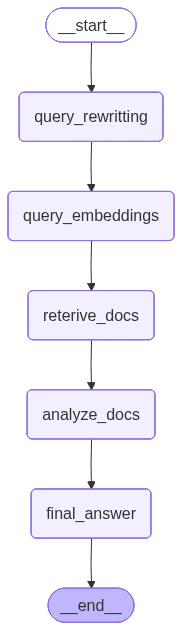

In [ ]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))